## Author<br>
Name: Zhihao Cui<br>
Institution: Hainan University, School of Mathematics and Statistics<br>
NO:20233002662

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import f1_score

RANDOM_STATE = 42

In [20]:
def build_mixed_dataset():
    """
    生成三类异常的合成数据集（标准化后）：
    1) 全局离群点：远离所有正常簇，用均匀分布产生
    2) 局部离群点：在正常簇附近但噪声极大，实际密度极低
    3) 稀疏簇：独立小簇，密度明显低于正常簇，但不完全孤立
    """
    rng = np.random.RandomState(RANDOM_STATE)

    # 正常簇：三个高斯分布区域，共400点
    x1, _ = make_blobs(n_samples=400, centers=[[-3.0, -3.0], [3.0, 3.0], [-2.0, 2.5]],
                       cluster_std=[0.6, 0.7, 0.55], random_state=RANDOM_STATE)

    # 全局离群：在[-10,10]范围内均匀随机，共20点
    x_global = rng.uniform(low=-10.0, high=10.0, size=(20, 2))

    # 局部离群：靠近正常簇中心[2.0, -3.0]，但标准差极小（0.18），形成孤立小群
    local_center = rng.normal(loc=[2.0, -3.0], scale=0.4, size=(1, 2))
    x_local = rng.normal(loc=local_center, scale=0.18, size=(12, 2))

    # 稀疏簇：位于[-5.0,0.8]附近，标准差较大(1.2)，密度低
    sparse_center = rng.normal(loc=[-5.0, 0.8], scale=0.4, size=(1, 2))
    x_sparse = rng.normal(loc=sparse_center, scale=1.2, size=(15, 2))

    # 合并所有异常点，标签为1
    x_out = np.vstack([x_global, x_local, x_sparse])
    y_out = np.ones(len(x_out), dtype=int)

    x = np.vstack([x1, x_out])
    y_true = np.hstack([np.zeros(len(x1), dtype=int), y_out])

    # 标准化：使各维尺度一致，避免量纲影响
    x = StandardScaler().fit_transform(x)
    return x, y_true

方法1：Z-score

In [21]:
def detect_zscore(x):
    """
    计算每个点在每个维度上的Z-score平方和（卡方距离），
    用95%分位数作为阈值。适合检测全局离群点，对局部离群不敏感。
    """
    z = stats.zscore(x, axis=0)
    dist_sq = np.sum(z ** 2, axis=1)
    # 阈值取95%分位数：默认认为5%的点为异常（适用于教学演示）
    threshold = np.percentile(dist_sq, 95)
    y_pred = (dist_sq > threshold).astype(int)
    return y_pred, dist_sq

方法2：IQR

In [22]:
def detect_iqr(x):
    """
    对每个维度独立使用IQR（四分位距），任一维度超过上下限2×IQR即判为异常。
    2倍IQR是较为宽松的阈值，突出极端值。适合检测全局离群。
    """
    max_score = np.zeros(len(x))
    for j in range(x.shape[1]):
        q1 = np.percentile(x[:, j], 25)
        q3 = np.percentile(x[:, j], 75)
        iqr = q3 - q1
        lo = q1 - 2.0 * iqr
        hi = q3 + 2.0 * iqr
        # 计算偏离度：超出边界越多得分越高，然后取各维最大值
        sc = np.maximum(0, (lo - x[:, j]) / (iqr + 1e-8), (x[:, j] - hi) / (iqr + 1e-8))
        max_score = np.maximum(max_score, sc)
    y_pred = (max_score > 0).astype(int)
    return y_pred, max_score

方法3：DBSCAN

In [23]:
def detect_dbscan(x, eps=0.35, min_samples=10):
    """
    密度聚类：将低密度区域的点标记为噪声（异常）。
    参数eps=0.35是经过调参适合本数据集的邻域半径，min_samples=10为密度阈值。
    该法对局部离群和稀疏簇最敏感，但可能漏掉全局孤立点（因为全局点单独成簇？需视eps而定）。
    """
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(x)
    y_pred = (labels == -1).astype(int)
    return y_pred, None

方法4：Isolation Forest

In [24]:
def detect_iforest(x):
    """
    随机隔离森林：异常点更容易被少数特征分割出来。
    contamination=0.1预设异常比例为10%，与真实比例接近。
    输出得分越低（负值越小）越异常，这里取反以便统一排序。
    """
    model = IsolationForest(n_estimators=200, contamination=0.1, random_state=RANDOM_STATE)
    pred = model.fit_predict(x)
    y_pred = (pred == -1).astype(int)
    score = -model.decision_function(x)   # 转为越大越异常
    return y_pred, score

方法5：Local Outlier Factor

In [25]:
def detect_lof(x):
    """
    局部离群因子：比较点与邻居的密度，密度显著低于邻居则为异常。
    n_neighbors=18控制局部邻域大小，contamination=0.1预设异常比例。
    擅长检测局部离群点，但对全局孤立点可能不如Z-score/IQR敏感。
    """
    model = LocalOutlierFactor(n_neighbors=18, contamination=0.1)
    pred = model.fit_predict(x)
    y_pred = (pred == -1).astype(int)
    score = -model.negative_outlier_factor_   # 转化为越大越异常
    return y_pred, score

批量运行所有方法并评估

In [26]:
def run_all(x, y_true):
    methods = [
        ("Z-score", detect_zscore),
        ("IQR", detect_iqr),
        ("DBSCAN", detect_dbscan),
        ("IsolationForest", detect_iforest),
        ("LocalOutlierFactor", detect_lof),
    ]
    out = []
    for name, fn in methods:
        y_pred, score = fn(x)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        out.append({
            "method": name,
            "y_pred": y_pred,
            "score": score,
            "f1": round(f1, 4),
            "n_detected": int(y_pred.sum()),
        })
    return out


def print_summary_table(out):
    """打印各方法检出异常数和F1分数对比表"""
    df = pd.DataFrame([{
        "方法": r["method"],
        "检出异常数": r["n_detected"],
        "F1得分": r["f1"],
    } for r in out])
    df = df.sort_values("F1得分", ascending=False).reset_index(drop=True)
    print("\n[异常检测3 ---- 五方法对比]")
    print(df.to_string(index=False))


def plot_comparison(x, y_true, out):
    """
    绘制真实标签和各方法预测结果的散点图。
    第一子图为真实异常（红色×），后续为各方法预测异常（红色×）和正常（绿色圆点）。
    """
    total = len(out) + 1
    ncols = 3
    nrows = int(np.ceil(total / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    # 删除多余的子图（当子图数量多于所需时）
    for j in range(total, len(axes)):
        fig.delaxes(axes[j])

    # 真实标签图
    ax0 = axes[0]
    ax0.scatter(x[y_true == 0, 0], x[y_true == 0, 1], s=16, c="steelblue", alpha=0.7, label="normal")
    ax0.scatter(x[y_true == 1, 0], x[y_true == 1, 1], s=26, c="crimson", marker="x", label="true outlier")
    ax0.set_title("Ground Truth")
    ax0.legend(loc="best", fontsize=9)
    ax0.grid(alpha=0.25)

    # 各方法预测结果图
    for i, r in enumerate(out, start=1):
        ax = axes[i]
        yp = r["y_pred"]
        ax.scatter(x[yp == 0, 0], x[yp == 0, 1], s=16, c="mediumseagreen", alpha=0.7, label="pred normal")
        ax.scatter(x[yp == 1, 0], x[yp == 1, 1], s=26, c="crimson", marker="x", label="pred outlier")
        ax.set_title("{}\nF1={:.3f}, detected={}".format(r["method"], r["f1"], r["n_detected"]))
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


[异常检测3 ---- 五方法对比]
                方法  检出异常数   F1得分
   IsolationForest     45 0.8261
            DBSCAN     28 0.7467
LocalOutlierFactor     45 0.6304
           Z-score     23 0.4000
               IQR      0 0.0000


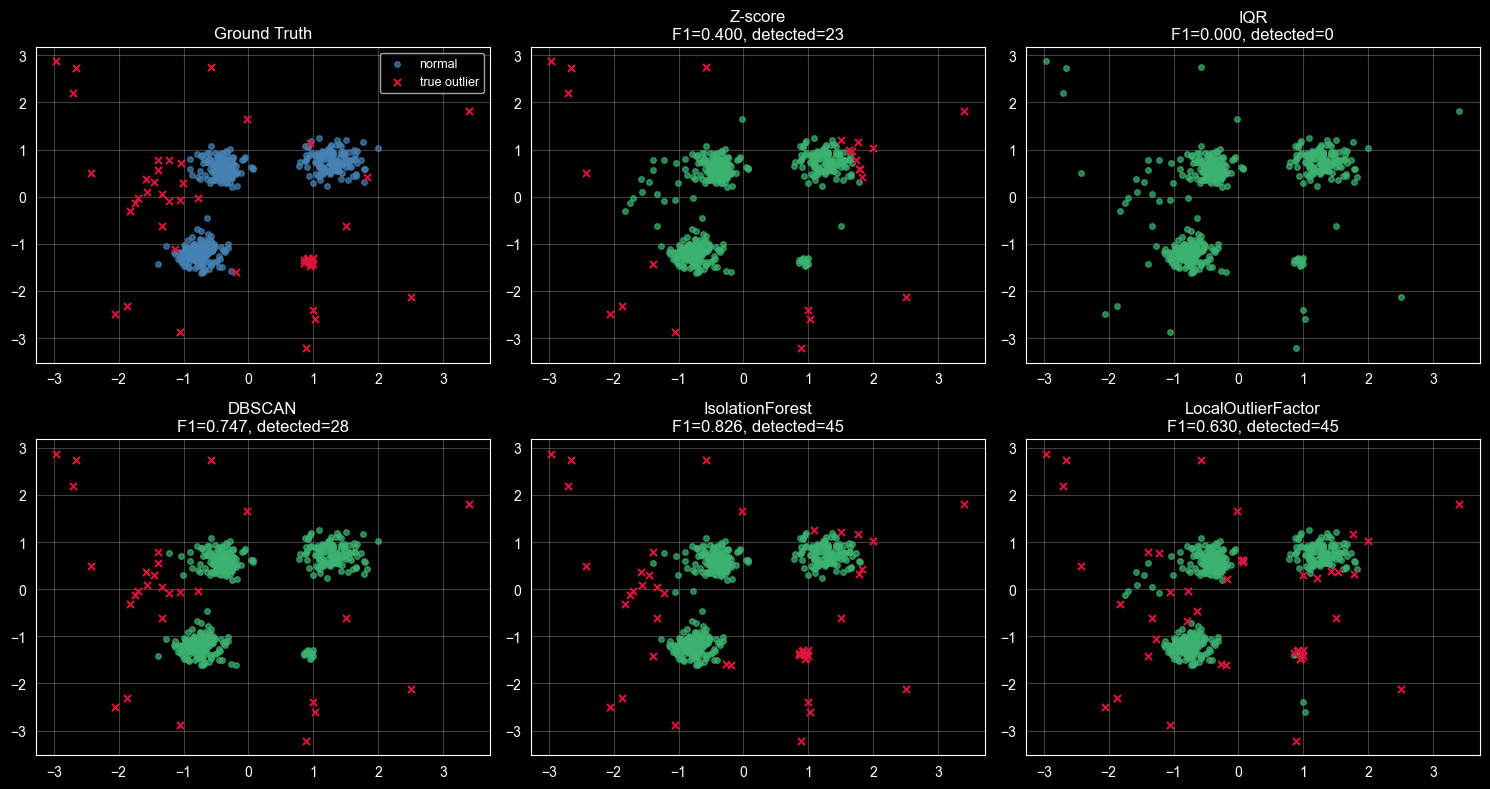

In [27]:
x, y_true = build_mixed_dataset()
out = run_all(x, y_true)
print_summary_table(out)
plot_comparison(x, y_true, out)   # 如果想要显示图形